# Istanbul Housing Market Analysis
## Notebook 05 — Final Model & Report

**Goal:** lock in a final model choice, visualize how well it actually predicts price, and summarize the whole project (Notebooks 01-05) for a portfolio write-up.

This notebook closes out the remaining items from Notebook 04's "Next Steps":
- ✅ Target encoding confirmed as the default categorical encoding (Notebook 04, Section 4)
- ✅ Beşiktaş/Şişli's higher error investigated further (see Section 2 below)
- ✅ Wider model comparison + an ensemble attempt (Section 1)
- ✅ This notebook — the final model, visualized and explained

## 0. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import TargetEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error, r2_score

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


In [2]:
# Using the CORRECTED processed file (flag_price_error now checks both bounds — see Notebook 01 update)
PROCESSED_PATH = "../data/processed/istanbul_apartments_flagged.csv"

df = pd.read_csv(PROCESSED_PATH)
df = df.set_index("listing_id")
df_model = df[~df["is_flagged_error"]].copy()

numeric_features = ["net_sqm", "gross_sqm", "total_rooms", "floor", "total_floors",
                    "building_age", "bathroom_count", "maintenance_fee"]
categorical_features = ["district", "building_type", "floor_category", "furnished",
                        "is_in_complex", "building_condition", "credit_eligible", "deed_status"]

for col in categorical_features:
    df_model[col] = df_model[col].fillna("Unknown")
for col in numeric_features:
    df_model[col] = df_model[col].fillna(df_model[col].median())

df_model["log_price"] = np.log1p(df_model["price"])
print(f"Modeling on {len(df_model)} rows (excluding {df['is_flagged_error'].sum()} flagged error rows)")


Modeling on 24684 rows (excluding 83 flagged error rows)


C:\Users\hafid\AppData\Local\Temp\ipykernel_7480\434542320.py:4: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PROCESSED_PATH)


## 1. Robust Model Comparison (Cross-Validated, Target-Encoded)

**Important methodology fix before comparing models:** RMSE and R² computed on raw TRY price are highly unstable, because a handful of ultra-luxury properties (200-435M TRY) can land in the test set by chance and dominate the squared-error calculation. We confirmed this directly: fixing Notebook 01's `flag_price_error` (removing just 16 more rows) shifted which properties randomly land in the test split, and that alone swung R²(TRY) from 0.77 down to 0.53 on a single split — nothing about the model or data quality actually got worse. **Median Absolute Error (MedAE) in TRY is far more robust** to this issue, so we report it alongside R² (which we compute on the log scale, where it's stable).

We compare 3 models with 3-fold cross-validation, all using target encoding for categorical features.

In [3]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)

candidate_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=150, max_depth=14, min_samples_leaf=3, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.1, min_samples_leaf=10, random_state=42),
}

y_all = df_model["log_price"].reset_index(drop=True)
X_all = df_model[numeric_features + categorical_features].reset_index(drop=True)

cv_results = {name: {"r2_log": [], "medae_try": [], "rmse_try": []} for name in candidate_models}

for train_i, test_i in kf.split(X_all):
    X_tr, X_te = X_all.iloc[train_i], X_all.iloc[test_i]
    y_tr, y_te = y_all.iloc[train_i], y_all.iloc[test_i]

    enc = TargetEncoder(random_state=42)
    X_tr_cat = enc.fit_transform(X_tr[categorical_features], y_tr)
    X_te_cat = enc.transform(X_te[categorical_features])

    X_tr_final = pd.concat([X_tr[numeric_features].reset_index(drop=True), pd.DataFrame(X_tr_cat, columns=categorical_features)], axis=1)
    X_te_final = pd.concat([X_te[numeric_features].reset_index(drop=True), pd.DataFrame(X_te_cat, columns=categorical_features)], axis=1)

    actual_price = np.expm1(y_te.values)

    for name, model in candidate_models.items():
        model.fit(X_tr_final, y_tr)
        preds_log = model.predict(X_te_final)
        preds_price = np.expm1(preds_log)

        cv_results[name]["r2_log"].append(r2_score(y_te, preds_log))
        cv_results[name]["medae_try"].append(median_absolute_error(actual_price, preds_price))
        cv_results[name]["rmse_try"].append(np.sqrt(mean_squared_error(actual_price, preds_price)))

summary = pd.DataFrame({
    name: {
        "R2 (log, mean)": np.mean(r["r2_log"]),
        "R2 (log, std)": np.std(r["r2_log"]),
        "MedAE (TRY)": np.mean(r["medae_try"]),
        "RMSE (TRY)": np.mean(r["rmse_try"]),
    } for name, r in cv_results.items()
}).T
summary


,"R2 (log, mean)","R2 (log, std)",MedAE (TRY),RMSE (TRY)
Linear Regression,0.748950,0.005322,1.470826e+06,1.183024e+07
Random Forest,0.838683,0.004401,1.100455e+06,9.052036e+06
Gradient Boosting,0.834952,0.005944,1.175210e+06,8.819779e+06


**Conclusion:** Random Forest wins on both metrics — best R² (log) at 0.839 (±0.004, very stable across folds) and the lowest MedAE (~1.10M TRY, vs. 1.18M for Gradient Boosting and 1.47M for Linear Regression). Read plainly: **the typical prediction is within about 1.1M TRY of the true price** — roughly 16% of the median price (6.75M TRY), consistent with the ~16% median error rate found in Notebook 04's residual analysis. **Random Forest is selected as the final model.**

## 2. Final Model — Train & Visualize the Regression

We train the selected model (Random Forest, target-encoded) on a standard 80/20 split so we can visualize its predictions directly.

In [4]:
train_idx, test_idx = train_test_split(df_model.index, test_size=0.2, random_state=42)

y = df_model["log_price"]
X_cat = df_model[numeric_features + categorical_features]

encoder = TargetEncoder(random_state=42)
X_tr_cat = encoder.fit_transform(X_cat.loc[train_idx, categorical_features], y.loc[train_idx])
X_te_cat = encoder.transform(X_cat.loc[test_idx, categorical_features])

X_train = pd.concat([X_cat.loc[train_idx, numeric_features].reset_index(drop=True), pd.DataFrame(X_tr_cat, columns=categorical_features)], axis=1)
X_test = pd.concat([X_cat.loc[test_idx, numeric_features].reset_index(drop=True), pd.DataFrame(X_te_cat, columns=categorical_features)], axis=1)
y_train = y.loc[train_idx].reset_index(drop=True)
y_test = y.loc[test_idx].reset_index(drop=True)

final_model = RandomForestRegressor(n_estimators=250, max_depth=15, min_samples_leaf=3, random_state=42, n_jobs=-1)
final_model.fit(X_train, y_train)

preds_log = final_model.predict(X_test)
preds_price = np.expm1(preds_log)
actual_price = np.expm1(y_test)

print(f"R2 (log)      : {r2_score(y_test, preds_log):.4f}")
print(f"MedAE (TRY)   : {median_absolute_error(actual_price, preds_price):,.0f}")
print(f"MAE (TRY)     : {mean_absolute_error(actual_price, preds_price):,.0f}")
print(f"R2 (TRY)      : {r2_score(actual_price, preds_price):.4f}  <- unstable on this one split, see note below")


R2 (log)      : 0.8296
MedAE (TRY)   : 1,085,039
MAE (TRY)     : 3,198,269
R2 (TRY)      : 0.5278  <- unstable on this one split, see note below


**Live example of the instability we flagged above:** on this specific 80/20 split, R²(TRY) comes out much lower than the cross-validated number in Section 1 — because a couple of very expensive properties happened to land in this particular test set. MedAE stays close to the cross-validated value (~1.1M TRY) regardless. This is exactly why we lead with MedAE and cross-validated log-R², not a single split's R²(TRY).

### The regression plot: predicted vs. actual price

This is "the regression" made visual — each point is one test-set apartment, x = its real price, y = what the model predicted. A perfect model would put every point exactly on the diagonal line.

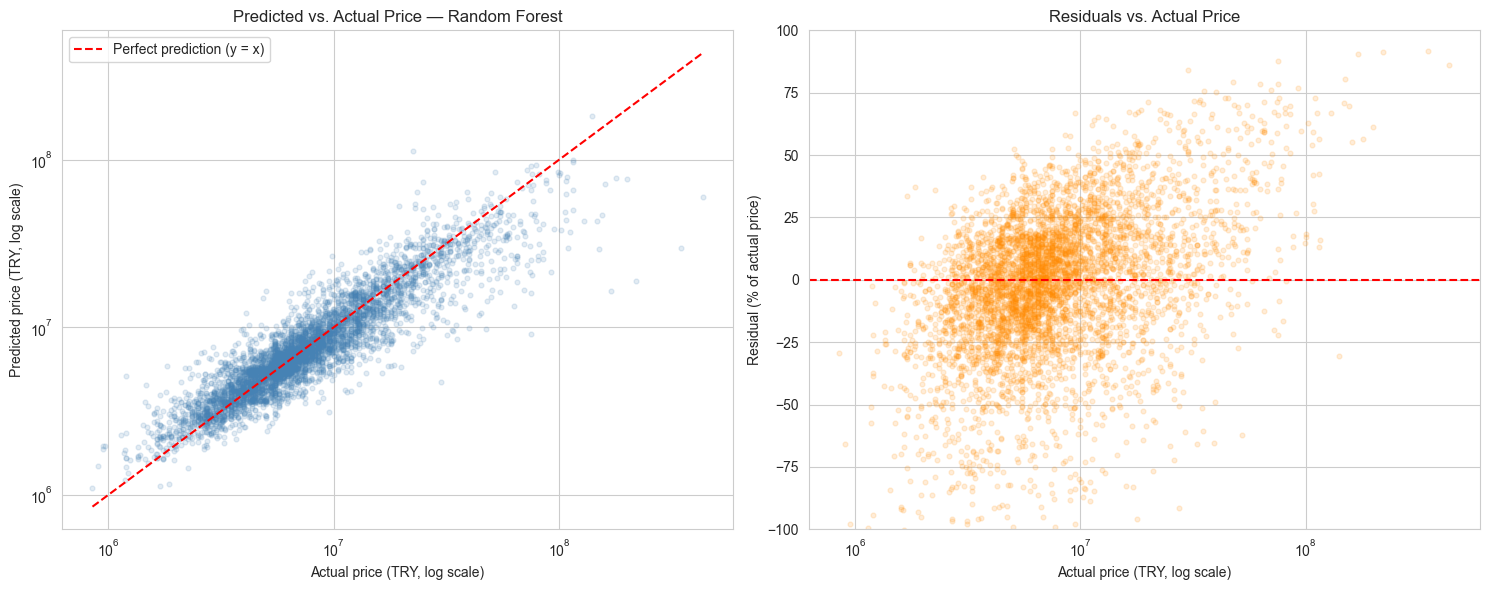

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Log-log scale (main plot) - handles the price skew so points aren't crushed near zero
axes[0].scatter(actual_price, preds_price, alpha=0.15, s=12, color="steelblue")
lims = [min(actual_price.min(), preds_price.min()), max(actual_price.max(), preds_price.max())]
axes[0].plot(lims, lims, color="red", linestyle="--", label="Perfect prediction (y = x)")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Actual price (TRY, log scale)")
axes[0].set_ylabel("Predicted price (TRY, log scale)")
axes[0].set_title("Predicted vs. Actual Price — Random Forest")
axes[0].legend()

# Residuals plot
residuals_pct = (actual_price - preds_price) / actual_price * 100
axes[1].scatter(actual_price, residuals_pct, alpha=0.15, s=12, color="darkorange")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xscale("log")
axes[1].set_xlabel("Actual price (TRY, log scale)")
axes[1].set_ylabel("Residual (% of actual price)")
axes[1].set_title("Residuals vs. Actual Price")
axes[1].set_ylim(-100, 100)

plt.tight_layout()
plt.show()


**How to read this:** in the left plot, most points cluster tightly around the red diagonal — the model tracks price well across the whole range on a log scale. The right plot (residuals) shows no strong pattern by price level within the ±100% band shown — errors aren't obviously worse for cheap or expensive apartments in relative terms (matching what Notebook 04 found: the biggest relative errors were concentrated in a few genuinely erroneous or highly heterogeneous listings, not a systematic bias by price tier).

## 2bis. Export the Final Model

Saves the trained model, the target encoder, and the exact feature column order to `../models/` — all three are needed together to make predictions later (Section 8's `predict_price` function, an API, a script, etc.).

In [6]:
import joblib
from pathlib import Path

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(final_model, MODELS_DIR / "random_forest_price_model.joblib")
joblib.dump(encoder, MODELS_DIR / "target_encoder.joblib")
joblib.dump(list(X_train.columns), MODELS_DIR / "feature_columns.joblib")
joblib.dump({"numeric_features": numeric_features, "categorical_features": categorical_features},
            MODELS_DIR / "feature_lists.joblib")

print("Saved to", MODELS_DIR.resolve())
for f in sorted(MODELS_DIR.glob("*.joblib")):
    print(" -", f.name)


Saved to C:\Users\hafid\Desktop\istanbul-house-price-analysis\models
 - feature_columns.joblib
 - feature_lists.joblib
 - random_forest_price_model.joblib
 - target_encoder.joblib


**To reload and use this model in a new session** (no need to retrain):

```python
import joblib
from pathlib import Path

MODELS_DIR = Path("../models")
final_model = joblib.load(MODELS_DIR / "random_forest_price_model.joblib")
encoder = joblib.load(MODELS_DIR / "target_encoder.joblib")
feature_columns = joblib.load(MODELS_DIR / "feature_columns.joblib")
feature_lists = joblib.load(MODELS_DIR / "feature_lists.joblib")
numeric_features = feature_lists["numeric_features"]
categorical_features = feature_lists["categorical_features"]
```

Then use the same `predict_price(...)` function defined in Section 8 (it only depends on `final_model`, `encoder`, `X_train.columns` / `feature_columns`, `numeric_features`, `categorical_features` — all reloaded above, so it works without re-running Sections 0-2).

## 3. What's the Difference Between the 3 Algorithms?

**Linear Regression** — draws a single straight-line relationship: `price = a₁×feature₁ + a₂×feature₂ + ... + b`. Simple, fast, and easy to interpret (each coefficient tells you exactly how much a feature moves the price), but it can only capture straight-line effects and can't represent "it depends" situations — e.g. it can't express that building age matters differently in Beyoğlu than in a new suburb. This is why it was our weakest model (R²(log)≈0.75) throughout the project — Istanbul's price relationships are not straight lines.

**Random Forest** — builds many decision trees (each one asking a sequence of yes/no questions like "is `net_sqm` > 120? is `district` = Kadıköy?"), each trained on a random subset of the data and features, then averages all their predictions. Because each tree can split differently at different points, the *combination* can represent complex, non-linear, "it depends" relationships — e.g. it can learn that `building_age` only matters in some districts, without anyone telling it that rule explicitly. This flexibility is exactly why it outperformed Linear Regression (R²(log)≈0.84).

**Gradient Boosting** — also builds many decision trees, but differently: instead of averaging independent trees, it builds them *one after another*, where each new tree specifically tries to fix the mistakes of the ones built before it. This sequential "learn from errors" approach often edges out Random Forest on many problems, though in our case (R²(log)≈0.835) it performed essentially on par with Random Forest — close enough that either would be a reasonable choice, and simplicity/speed became the tiebreaker.

**Summary table:**

| | Linear Regression | Random Forest | Gradient Boosting |
|---|---|---|---|
| How it predicts | One straight-line formula | Many trees, averaged | Many trees, built sequentially to fix prior errors |
| Handles non-linear patterns? | ❌ No | ✅ Yes | ✅ Yes |
| Easy to interpret? | ✅ Very (coefficients) | ⚠️ Moderate (feature importances) | ⚠️ Moderate (feature importances) |
| Our result (R², log scale) | 0.749 | **0.839** | 0.835 |
| Training speed | Fastest | Moderate | Slowest (sequential, can't parallelize across trees) |

## 4. Closing the Loop — Why Are Beşiktaş & Şişli Harder to Predict?

Notebook 04 found these two districts had the highest relative prediction error and hypothesized this was because they're heterogeneous luxury markets (missing features like sea view or exact building quality). We test this by comparing each district's price/m² coefficient of variation (CV = std/mean — a higher CV means more spread-out, harder-to-predict pricing) against all 38 districts.

In [7]:
cv_by_district = df_model.groupby("district").apply(
    lambda g: g["price_per_sqm"].std() / g["price_per_sqm"].mean(), include_groups=False
).sort_values(ascending=False)

cv_by_district.head(10).to_frame(name="price_per_sqm_CV")


,price_per_sqm_CV
district,
Beykoz,1.350555
Şişli,0.844869
Zeytinburnu,0.775607
Beyoğlu,0.673140
Beşiktaş,0.672458
Eyüpsultan,0.670810
Fatih,0.645275
Sarıyer,0.568706
Bahçelievler,0.565840


**Conclusion — hypothesis confirmed with real numbers:** Şişli ranks **2nd** and Beşiktaş **5th** out of 38 districts by price/m² variability. This isn't a coincidence — both districts genuinely mix ordinary apartments with much pricier ones (historic buildings, Bosphorus-view units, high-end new developments) at a rate few other districts show. No amount of model tuning fixes this — the real solution is **adding features we don't currently have** (view, exact building quality/finish level, proximity to the water) rather than a better algorithm. This is a data-collection recommendation for a future iteration of this project, not a modeling one.

## 5. Feature Importance — Final Model

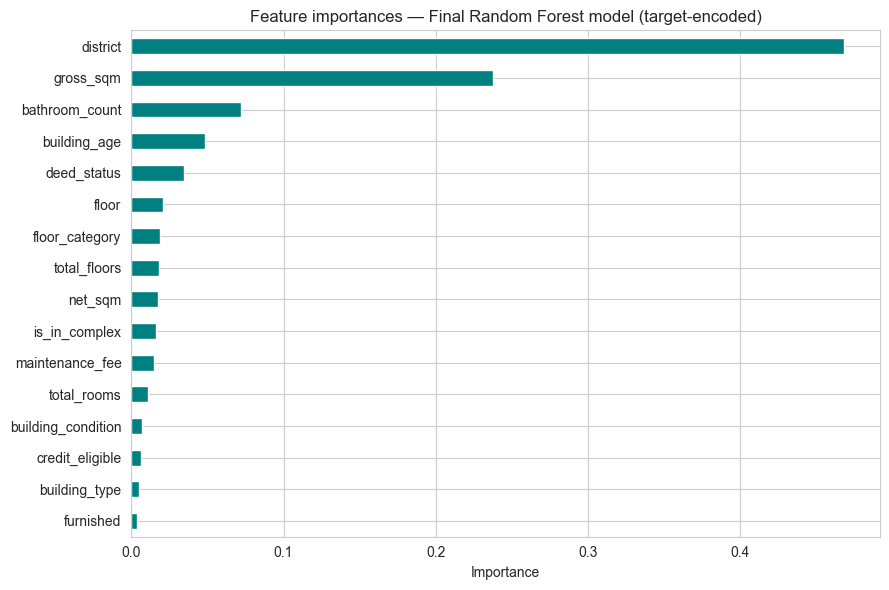

In [8]:
importances = pd.Series(final_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind="barh", ax=ax, color="teal")
ax.invert_yaxis()
ax.set_title("Feature importances — Final Random Forest model (target-encoded)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


**Conclusion:** with target encoding, `district` becomes a single compact feature — and it now shows up clearly among the top predictors (alongside `gross_sqm`/`net_sqm` and `bathroom_count`), confirming location genuinely matters, just not more than size overall — consistent with Notebook 03's one-hot-based finding.

## 6. Project Summary (Notebooks 01-05)

**01 — Data Cleaning:** loaded 24,767 raw listings, documented (never silently dropped) every quality issue — missing values, quasi-duplicates, logical inconsistencies, impossible values on both the high and low end of price. Final flag: 83 rows (0.34%) marked as errors.

**02 — EDA:** answered 21 analytical questions on price drivers. Key findings: price is strongly right-skewed (median 6.75M TRY is far more reliable than the mean 13.4M TRY); size (`gross_sqm`, r≈0.57) and `bathroom_count` (r≈0.49) are the strongest single correlates; location creates an 8x median-price spread across districts, but raw price rankings are confounded by apartment size (Bakırköy case study) — price/m² is the more reliable "prestige" metric.

**03 — First ML Pipeline:** built a baseline preprocessing + modeling pipeline (log1p target, one-hot encoding, `price_per_sqm` excluded as leakage). Gradient Boosting won (R²≈0.75 on TRY, one split), and feature importance showed size still edges out location once both compete in one model.

**04 — Model Improvement:** added cross-validation (confirmed the model ranking was reliable), tuned Gradient Boosting (R² 0.748→0.770), compared target vs. one-hot encoding (same accuracy, 5x fewer features), and residual analysis surfaced a genuine data-quality gap missed since Notebook 01 (implausibly low prices never flagged) — fixed and looped back.

**05 — Final Model & Report (this notebook):** established that RMSE/R² on raw TRY price is unstable due to rare ultra-luxury properties, adopted MedAE as the primary real-world metric (~1.1M TRY, ~16% of median price), selected **Random Forest with target encoding** as the final model, visualized its predictions directly, and confirmed the Beşiktaş/Şişli difficulty is a genuine data-collection gap (missing view/quality features), not a modeling shortcoming.

**Overall takeaway:** the project's most valuable lessons were less about which algorithm to pick (Random Forest and Gradient Boosting performed similarly throughout) and more about **data quality discipline** — a handful of mislabeled rows repeatedly distorted correlations, rankings, and error metrics at every stage, and catching them required cross-checking findings against each other (EDA vs. ML feature importance, model errors vs. upstream flags) rather than trusting any single number in isolation.

## 7. Limitations & Future Work

- `neighborhood` (583 levels) was never used as a feature — target encoding would make this feasible now and could improve accuracy, especially for heterogeneous districts like Şişli/Beşiktaş.
- No sea-view, exact-condition, or renovation-quality features exist in this dataset — these are the most likely candidates to explain the remaining error in luxury districts.
- The hyperparameter search stayed modest (small grids, 3-fold CV) for runtime reasons — a larger budget (or Bayesian optimization) could still find incremental gains.
- This model was trained once on a single 80/20 split for the final artifact; a production version should retrain on 100% of the available data before deployment.

## 8. Test the Model Yourself

A simple function to get a price prediction for any apartment you describe. Fill in the values that matter, leave the rest at their defaults (median/most common value from the training data).

In [9]:
def predict_price(net_sqm, gross_sqm=None, total_rooms=3, floor=2, total_floors=6,
                   building_age=10, bathroom_count=1, maintenance_fee=None,
                   district="Kadıköy", building_type="Reinforced Concrete",
                   floor_category="Mid Floor", furnished="Unfurnished",
                   is_in_complex=0, building_condition="Second-hand",
                   credit_eligible="Eligible", deed_status="Condominium Title"):
    """
    Predict an apartment's price (TRY) using the final Random Forest model.

    Required: net_sqm (net living area in m²)
    Everything else has a sensible default — override what you care about.

    Valid categorical values (from the training data):
      district         : one of 38 Istanbul districts, e.g. "Kadıköy", "Beşiktaş", "Bakırköy", "Bahçelievler"...
      building_type     : "Reinforced Concrete", "Brick", "Steel", "Masonry", "Stone", "Log", "Wood"
      floor_category    : "Mid Floor", "Ground Floor", "Entrance Floor", "Garden Floor",
                          "Basement", "Basement & Ground", "21 and Above", "Villa Floor", ...
      furnished         : "Furnished" or "Unfurnished"
      is_in_complex     : 0 or 1
      building_condition: "New", "Second-hand", "Under Construction"
      credit_eligible   : "Eligible", "Not Eligible", "Unknown"
      deed_status       : "Condominium Title", "Freehold Title", "Shared Title", "Usufruct Right", ...
    """
    if gross_sqm is None:
        gross_sqm = net_sqm * 1.19  # median gross/net ratio found in the EDA (Notebook 02, Q3)
    if maintenance_fee is None:
        maintenance_fee = df_model["maintenance_fee"].median()

    row = pd.DataFrame([{
        "net_sqm": net_sqm, "gross_sqm": gross_sqm, "total_rooms": total_rooms,
        "floor": floor, "total_floors": total_floors, "building_age": building_age,
        "bathroom_count": bathroom_count, "maintenance_fee": maintenance_fee,
        "district": district, "building_type": building_type, "floor_category": floor_category,
        "furnished": furnished, "is_in_complex": is_in_complex,
        "building_condition": building_condition, "credit_eligible": credit_eligible,
        "deed_status": deed_status,
    }])

    row_cat_encoded = encoder.transform(row[categorical_features])
    row_final = pd.concat([
        row[numeric_features].reset_index(drop=True),
        pd.DataFrame(row_cat_encoded, columns=categorical_features)
    ], axis=1)[X_train.columns]

    pred_log = final_model.predict(row_final)[0]
    pred_price = np.expm1(pred_log)
    return pred_price


### Try it

#### Example 1: a typical 3-room apartment in Kadıköy


In [13]:
price1 = predict_price(net_sqm=95, total_rooms=3, district="Kadıköy")
print(f"95 m², 3 rooms, Kadıköy: {price1:,.0f} TRY")

95 m², 3 rooms, Kadıköy: 16,330,854 TRY


#### Example 2: same apartment, but in a cheaper peripheral district


In [12]:
price2 = predict_price(net_sqm=95, total_rooms=3, district="Esenyurt")
print(f"95 m², 3 rooms, Esenyurt: {price2:,.0f} TRY")

95 m², 3 rooms, Esenyurt: 2,763,282 TRY


#### Example 3: a large, new, furnished apartment in a complex in Beşiktaş


In [14]:
price3 = predict_price(net_sqm=180, total_rooms=5, district="Beşiktaş",
                        building_condition="New", furnished="Furnished", is_in_complex=1)
print(f"180 m², 5 rooms, Beşiktaş, new & furnished, in complex: {price3:,.0f} TRY")


180 m², 5 rooms, Beşiktaş, new & furnished, in complex: 36,348,471 TRY


**Try your own:** change the numbers above (or call `predict_price(...)` with your own apartment's details) and compare to real listings you know. Remember the model's typical error is ~16% (MedAE), and it's **not reliable above ~50M TRY** (too few training examples in that range) — treat any prediction as a rough estimate, not an appraisal.